<a href="https://colab.research.google.com/github/juampamuc/notebooks/blob/main/MICCAI_2024_Education_Challenge_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MICCAI Educational Challenge 2024


Author: Misaal Khan
Affiliations: Medical Technologies, IIT-AIIMS Jodhpur Joint Program, India

Can use these materials for all purposes as long as the data licenses apply.

# Implementing explainable AI (XAI) in medical imaging

# Introduction

The goal of this tutorial is to implement explainable AI (XAI) techniques that are crucial for understanding and interpreting the decisions made by complex deep learning models, particularly in medical imaging.

In medical imaging, the transparency of AI models is critical for building trust with healthcare professionals and ensuring the safe and effective use of AI-driven diagnostics. This tutorial will guide you through implementing two fundamental XAI techniques: Gradient-weighted Class Activation Mapping (Grad-CAM) and SHapley Additive exPlanations (SHAP). These methods provide visual and feature-level insights into model predictions, helping to demystify the "black box" nature of AI models.

In this tutorial, you will explore how these XAI methods can be applied to a convolutional neural network (CNN) trained on X-ray images of lungs. You will learn to visualize which parts of an image influence model predictions and quantify feature importance, enhancing the interpretability of AI in medical applications.

The notebook is organized into several parts:

1. **Implementing a PyTorch Dataset**: Loading and preprocessing X-ray images for model training.
2. **Training a CNN Model**: Implementing and training a simple CNN on the lung X-ray dataset.
3. **Applying Grad-CAM for Visual Explanations**: Visualizing important regions in the images that contribute to the model's decision.
4. **Applying SHAP for Feature Attribution**: Quantifying feature contributions to the model's predictions.
5. **Interpreting and Visualizing Results**: Exploring visual explanations and understanding the model's behavior.

Let's import the required libraries:


In [ ]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/mps


Looking in indexes: https://download.pytorch.org/whl/mps
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS backend")
else:
    device = torch.device("cpu")
    print("Using CPU")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

Using MPS backend
mps


In [ ]:
# Install necessary packages
!pip install torch torchvision
!pip install matplotlib
!pip install numpy
!pip install pillow
!pip install shap
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.2/448.2 kB 1.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 2.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 5.6 MB/s eta 0:00:0000:0100:01
  Using cached lime-0.2.0.1.tar.gz (275 kB)
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 8.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.9/220.9 kB 4.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 8.0 MB/s eta 0:00:00a 0:00:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.4/315.4 kB 9.0 MB/s eta 0:00:00


  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283839 sha256=3988ea7c65d877ffc9d44bfeadecf1bc4bd43d05a8fecb542ee336299d34d9a1
  Stored in directory: /Users/misaalkhan/Library/Caches/pip/wheels/e6/a6/20/cc1e293fcdb67ede666fed293cb895395e7ecceb4467779546
Successfully built lime


In [ ]:
import torch
from torchvision import models, transforms
from torch.autograd import Function
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import pandas as pd
from torch.utils.tensorboard import SummaryWriter
import torch as tc

# Dataset Description

In this tutorial, we will use the **Chest X-Ray Images (Pneumonia)** dataset, which is available on Kaggle. This dataset contains a collection of 5,863 chest X-ray images (JPEG) organized into two categories: Pneumonia and Normal. The images were selected from retrospective cohorts of pediatric patients aged one to five years from Guangzhou Women and Children’s Medical Center.

The dataset is structured into three folders: `train`, `test`, and `val`, with subfolders for each image category. These images serve as an excellent resource for training and evaluating AI models in medical imaging tasks.

### Context

The chest X-ray images depict normal lungs as well as lungs affected by pneumonia. Normal images show clear lungs without abnormal opacification, whereas bacterial pneumonia typically shows focal lobar consolidation, and viral pneumonia shows a more diffuse interstitial pattern.


### Acknowledgements

- **Data Source:** [Mendeley Data](https://data.mendeley.com/datasets/rscbjbr9sj/2)
- **License:** CC BY 4.0
- **Citation:** [Cell Journal Article](http://www.cell.com/cell/fulltext/S0092-8674(18)30154-5)


---

For the purposes of this tutorial, we will demonstrate how to use this dataset to implement explainable AI techniques that help interpret model predictions in medical imaging.


# How to Set Up Kaggle API Credentials

To download datasets directly from Kaggle into your Google Colab notebook, you need to authenticate with the Kaggle API using a `kaggle.json` file. Follow these steps to obtain and use this file:

## Step 1: Log in to Kaggle

- Go to [Kaggle](https://www.kaggle.com/) and sign in to your account. If you don't have an account, you will need to create one.

## Step 2: Access Account Settings

- Click on your profile picture in the top right corner of the Kaggle website.
- Select **Account** from the dropdown menu to navigate to your account settings page.

## Step 3: Create API Token

- Scroll down to the **API** section of your account settings page.
- Click on **Create New API Token**. This will download a file named `kaggle.json` to your computer. This file contains your username and API key.

## Step 4: Upload `kaggle.json` to Colab

To use the Kaggle API in Colab, you need to upload the `kaggle.json` file:

1. Run the following code to upload the file:


In [ ]:
!pip install ipywidgets


In [ ]:
import ipywidgets as widgets
from IPython.display import display
from io import BytesIO

# Create an upload widget
uploader = widgets.FileUpload(accept='.json', multiple=False)

# Display the widget
display(uploader)

# Function to read the uploaded file after it has been uploaded
def process_uploaded_file(uploaded_file):
    if uploaded_file:
        # Get the file content
        file_content = BytesIO(uploader.value[next(iter(uploader.value))]['content'])
        return file_content
    else:
        return None

# You can access the uploaded file content later by calling:
uploaded_file_content = process_uploaded_file(uploader.value)


if uploaded_file_content:
    # Convert the content to a JSON object
    kaggle_json_content = json.load(uploaded_file_content)

    # Create the Kaggle folder if it doesn't exist
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

    # Write the JSON content to the kaggle.json file
    with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
        json.dump(kaggle_json_content, f)

    # Change permissions for the kaggle.json file
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

    print("kaggle.json file has been successfully uploaded and configured.")
else:
    print("kaggle.json upload failed. Please re-upload the file.")


FileUpload(value=(), accept='.json', description='Upload')

In [ ]:
import ipywidgets as widgets
from IPython.display import display
from io import BytesIO
import json
import os


# Install Kaggle API
!pip install kaggle

# Download the Chest X-Ray Images (Pneumonia) dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Unzip the dataset
!unzip chest-xray-pneumonia.zip


FileUpload(value=(), accept='.json', description='Upload')

kaggle.json upload failed. Please re-upload the file.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 985.6 kB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.0/163.0 kB 2.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.2/78.2 kB 3.1 MB/s eta 0:00:00
  Created wheel for kaggle: filename=kaggle-1.6.17-py3-none-any.whl size=105789 sha256=2d05be2544eed32002883c17971a82c91a50db03e348de233539049a49f72a40
  Stored in directory: /Users/misaalkhan/Library/Caches/pip/wheels/a5/6f/7b/837915771e94e181fa3052822926444e34f725ca38e70be77e
Successfully built kaggle
  Attempting uninstall: certifi
    Found existing installation: certifi 2023.5.7
    Uninstalling certifi-2023.5.7:
      Successfully uninstalled certifi-2023.5.7
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100%|█████████████████████████████████████▉| 2.29G/2.29G [05:48<00:00, 7.

  inflating: chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0105-0001.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0107-0001.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0109-0001.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0110-0001.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/NORMAL/._IM-0111-0001.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/NORMAL/._NORMAL2-IM-0007-0001.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/NORMAL/._NORMAL2-IM-0012-0001.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/NORMAL/._NORMAL2-IM-0013-0001.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/NORMAL/._NORMAL2-IM-0019-0001.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/NORMAL/._NORMAL2-IM-0023-0001.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/NORMAL/._NORMAL2-IM-0027-0001.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/NORMAL/._NORMAL2-IM-0028-0001.jpeg  
  inflat

  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person133_bacteria_637.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person133_bacteria_638.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person134_bacteria_640.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person134_bacteria_641.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person134_bacteria_642.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person134_bacteria_643.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person134_bacteria_644.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person135_bacteria_646.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person135_bacteria_647.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person136_bacteria_648.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person136_bacteria_649.jpeg  

  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person57_virus_113.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person59_virus_116.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person60_virus_117.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person61_virus_118.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person62_virus_119.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person63_virus_121.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person64_virus_122.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person65_virus_123.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person66_virus_125.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person67_virus_126.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray/test/PNEUMONIA/._person69_virus_129.jpeg  
  inflating: chest_xray/__MACOSX/chest_xray

...

  inflating: chest_xray/train/PNEUMONIA/person612_bacteria_2477.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person612_bacteria_2478.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person612_virus_1179.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person613_bacteria_2479.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person613_virus_1181.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person614_bacteria_2480.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person614_bacteria_2481.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person614_bacteria_2483.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person614_virus_1183.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person615_virus_1184.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person616_bacteria_2487.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person616_virus_1186.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person617_bacteria_2488.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person617_virus_1187.jpeg  
  inflating: chest_xray/

  inflating: chest_xray/train/PNEUMONIA/person67_bacteria_333.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person67_bacteria_334.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person680_bacteria_2575.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person681_bacteria_2576.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person681_virus_1272.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person682_virus_1273.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person683_bacteria_2578.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person684_bacteria_2580.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person684_virus_1275.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person685_bacteria_2581.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person687_bacteria_2583.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person688_bacteria_2584.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person688_virus_1281.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person688_virus_1282.jpeg  
  inflating: chest_xray/t

  inflating: chest_xray/train/PNEUMONIA/person743_virus_1366.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person744_bacteria_2647.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person744_virus_1367.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person745_bacteria_2648.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person745_virus_1368.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person746_bacteria_2649.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person746_virus_1369.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person747_bacteria_2650.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person747_virus_1370.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person747_virus_1372.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person748_virus_1373.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person749_bacteria_2652.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person749_virus_1374.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person74_bacteria_361.jpeg  
  inflating: chest_xray/train/PN

  inflating: chest_xray/train/PNEUMONIA/person83_virus_156.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person840_bacteria_2758.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person840_bacteria_2759.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person841_bacteria_2760.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person841_bacteria_2761.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person841_virus_1481.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person842_bacteria_2762.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person842_virus_1483.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person843_bacteria_2763.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person843_virus_1485.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person844_virus_1487.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person845_virus_1489.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person846_bacteria_2766.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person846_virus_1491.jpeg  
  inflating: chest_xray/train

  inflating: chest_xray/train/PNEUMONIA/person945_virus_1616.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person946_bacteria_2871.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person947_bacteria_2872.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person947_virus_1618.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person949_bacteria_2874.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person949_virus_1620.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person94_virus_176.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person950_virus_1621.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person951_bacteria_2876.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person951_virus_1622.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person952_bacteria_2877.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person952_virus_1623.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person953_bacteria_2878.jpeg  
  inflating: chest_xray/train/PNEUMONIA/person954_bacteria_2879.jpeg  
  inflating: chest_xray/train

In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define the data directory
data_dir = 'chest_xray'

# Define the transformation for the images
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224
    transforms.ToTensor()           # Convert images to tensors
])

# Load the dataset
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Print dataset sizes
print(f'Train dataset size: {len(train_dataset)}')
print(f'Validation dataset size: {len(val_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')


Train dataset size: 5216
Validation dataset size: 16
Test dataset size: 624


## Part II - Running A simple CNN model for Classification

Define a CNN model

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(64 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 2)
        self.dropout = nn.Dropout(0.25)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(-1, 64 * 28 * 28)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Instantiate the model, define the loss function and the optimizer
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


Train a CNN model

In [ ]:
def train_model(model, train_loader, criterion, optimizer, num_epochs=1):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}')

train_model(model, train_loader, criterion, optimizer, num_epochs=5)


Epoch [1/5], Loss: 0.2596
Epoch [2/5], Loss: 0.0979
Epoch [3/5], Loss: 0.0756
Epoch [4/5], Loss: 0.0604
Epoch [5/5], Loss: 0.0483


Evaluate the model

In [ ]:
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Accuracy: {100 * correct / total:.2f}%')

evaluate_model(model, test_loader)


Accuracy: 74.52%


**Additional Notes**

**Batch Size:** You can adjust the batch_size in the DataLoader to fit your memory constraints.

**Epochs:** Modify the num_epochs to ensure the model trains sufficiently.

**Learning Rate:** The learning rate in the optimizer can be tuned for better convergence.

Visualise Some Results



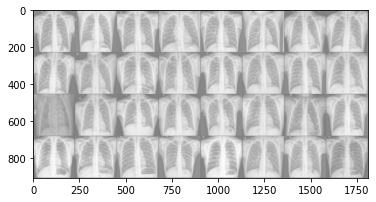

GroundTruth:  NORMAL NORMAL NORMAL NORMAL
Predicted:  NORMAL PNEUMONIA PNEUMONIA PNEUMONIA


In [ ]:
import torchvision as torchvision
## Define classes using the class-to-index mapping from the training dataset
classes = train_dataset.classes

# Visualize some predictions
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Print images and labels
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join('%5s' % classes[labels[j]] for j in range(4)))

# Show predictions
outputs = model(images.to(device))
_, predicted = torch.max(outputs, 1)
print('Predicted: ', ' '.join('%5s' % classes[predicted[j]] for j in range(4)))


# GradCAM

### Explanation of Grad-CAM and Guided Backpropagation

This diagram illustrates the process of generating visual explanations using **Grad-CAM** (Gradient-weighted Class Activation Mapping) and **Guided Backpropagation** in a Convolutional Neural Network (CNN).

1. **Input Image**:  
   The process begins with an input image (e.g., an image of a dog). This image is used as the input to the CNN model for classification.

2. **CNN Forward Pass**:  
   The input image is passed through the layers of the CNN. The network extracts features at different layers, producing **feature maps**. These feature maps represent various levels of abstraction in the image, capturing low-level patterns like edges and high-level patterns like textures and shapes.

3. **Rectified Feature Maps**:  
   After the image passes through the convolutional layers, the **ReLU** (Rectified Linear Unit) activation is applied, which removes negative activations. The resulting **rectified feature maps** (labeled as \(A\)) are crucial for the Grad-CAM calculation. These feature maps capture the important features of the image that influence the CNN's decision.

4. **Grad-CAM Heatmap Generation**:  
   Grad-CAM works by computing the **gradient** of the target class score (e.g., 'Tiger Cat') with respect to the feature maps \(A\). These gradients are then averaged across the feature map dimensions to obtain the **importance weights** for each feature map channel.  
   The weighted sum of these feature maps produces a coarse **heatmap** that highlights the regions of the image that are most important for the prediction.

5. **Guided Backpropagation**:  
   Guided Backpropagation is another method to visualize which pixels in the input image contributed the most to the prediction. In this process, the gradients are propagated backward through the network, but only positive gradients are allowed to pass through the ReLU layers. This produces a fine-grained visualization showing which specific parts of the image led to the classification decision.

6. **Combining Grad-CAM and Guided Backpropagation**:  
   The final output combines the **coarse Grad-CAM heatmap** and the **fine-grained Guided Backpropagation visualization** to generate a more detailed explanation of the model’s prediction. This combination, known as **Guided Grad-CAM**, merges the high-level importance regions with pixel-level details, offering a comprehensive visualization of which parts of the image influenced the model's decision the most.

7. **Class Prediction**:  
   The final fully connected layer outputs a prediction (e.g., 'Tiger Cat'), and the visual explanations help us understand which regions of the input image led to this classification.

By visualizing the regions of the image that influence the model’s predictions, Grad-CAM and Guided Backpropagation enhance interpretability, allowing us to trust and understand deep learning models in critical applications like medical diagnostics and other sensitive domains.

---


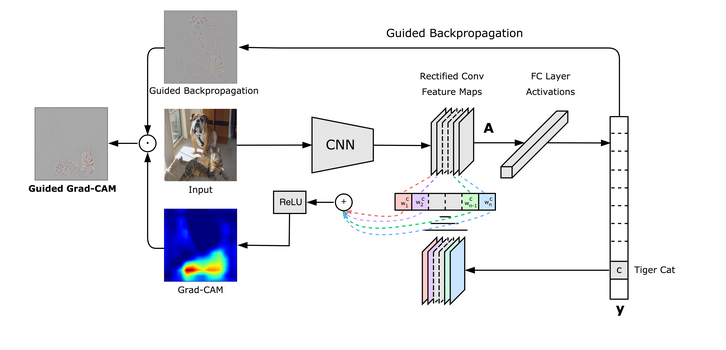





In [ ]:
import torch
from torch.autograd import Function
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Grad-CAM class
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate_cam(self, input_image, target_class):
        self.model.zero_grad()
        output = self.model(input_image)
        target = output[0][target_class]
        target.backward()

        # Global Average Pooling of gradients
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])

        # Weighting activations by gradients
        for i in range(self.activations.shape[1]):
            self.activations[0, i, :, :] *= pooled_gradients[i]

        # Create the CAM
        cam = torch.mean(self.activations, dim=1).squeeze().cpu().numpy()
        cam = np.maximum(cam, 0)  # ReLU to keep only positive values
        cam = cv2.resize(cam, (224, 224))  # Resize to match input image
        cam = cam - np.min(cam)
        cam = cam / np.max(cam)
        return cam

# Initialize the Grad-CAM
target_layer = model.conv3  # Choose the last convolutional layer
grad_cam = GradCAM(model, target_layer)


Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.


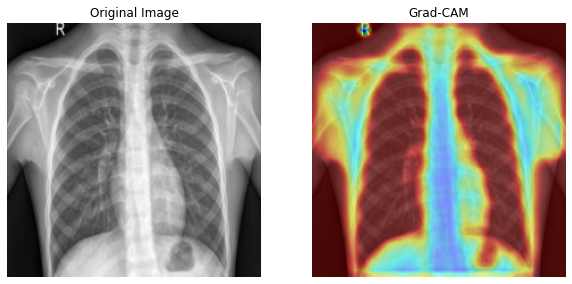

In [ ]:
# Get a single image from the test dataset
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Move the image to the device (GPU/CPU)
input_image = images[0].unsqueeze(0).to(device)
target_class = labels[0].item()

# Generate the CAM
cam = grad_cam.generate_cam(input_image, target_class)

# Convert the input image back to a NumPy array for visualization
input_image_np = input_image.cpu().numpy()[0].transpose(1, 2, 0)
input_image_np = input_image_np - np.min(input_image_np)
input_image_np = input_image_np / np.max(input_image_np)

# Overlay the CAM on the original image
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = np.float32(heatmap) / 255
cam_image = heatmap + np.float32(input_image_np)
cam_image = cam_image / np.max(cam_image)

# Plot the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(input_image_np)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cam_image)
plt.title('Grad-CAM')
plt.axis('off')
plt.show()


#Interpretation: In Grad-CAM visualizations, the heatmap represents the regions in the image that contributed most to the model’s decision. In the context of a lung X-ray, the model should ideally focus on areas with potential abnormalities (e.g., nodules or areas of opacity). If the heatmap highlights irrelevant regions, this may indicate a flaw in the model’s learning process.





# Tip: Its important to validate Grad-CAM results with domain experts, such as radiologists. The regions highlighted by the model should match clinical expectations. If discrepancies are found, further model tuning may be necessary.

In [ ]:
# Import necessary libraries
import torch
import shap
import numpy as np
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import datasets, models
import matplotlib.pyplot as plt


In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define the data directory
data_dir = 'chest_xray'

# Define the transformation for the images
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224
    transforms.ToTensor()           # Convert images to tensors
])

# Load the dataset
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Print dataset sizes
print(f'Train dataset size: {len(train_dataset)}')
print(f'Validation dataset size: {len(val_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')


Train dataset size: 5216
Validation dataset size: 16
Test dataset size: 624


#SHAP (SHapley Additive exPlanations)


---



**SHAP** (SHapley Additive exPlanations) is a powerful method for explaining the output of machine learning models. It leverages concepts from cooperative game theory (specifically the Shapley value) to attribute a prediction to its individual input features. SHAP values provide a way to quantify how each feature contributes to pushing the prediction toward a specific outcome.

1. **Feature Importance**:  
   SHAP values assign an importance score to each feature, indicating how much that feature contributes to the model's prediction. In a medical imaging context (e.g., predicting the presence of pneumonia in an X-ray), SHAP can help determine which pixel regions had the largest influence on the model’s diagnosis.

2. **SHAP Values for Feature Attribution**:  
   SHAP calculates the contribution of each feature by considering what the model's prediction would be with and without that specific feature. The goal is to quantify how much that feature alone contributes to the overall prediction. Positive SHAP values indicate that the feature pushes the prediction towards the positive class (e.g., a higher likelihood of pneumonia), while negative SHAP values pull the prediction away from that class.

3. **Visualization of SHAP Values**:  
   SHAP offers several visualization methods to help interpret feature contributions:
   - **Force Plots**: Show the overall prediction as a sum of the SHAP values for each feature, visualizing how different features contribute to pushing the prediction up or down.
   - **Summary Plots**: Provide a global view of feature importance across the dataset. Each dot represents a SHAP value for a particular feature in a single prediction, giving insight into how different features impact different predictions.
   - **Dependence Plots**: Show the relationship between a single feature and the model’s output, while taking into account the other features.
   
4. **SHAP in Medical Imaging**:  
   In medical imaging, SHAP values can be used to explain why the model predicted a certain diagnosis by attributing importance to different regions of the image. For instance, if the model predicts pneumonia from an X-ray, SHAP can highlight the pixel regions in the image that contributed the most to this prediction. These explanations can then be validated by radiologists to check if the model is focusing on clinically relevant areas of the image.

5. **Interpreting SHAP Results**:  
   When interpreting SHAP results, it is important to look for features (or regions of the image) that consistently have high positive or negative SHAP values across multiple samples. If irrelevant regions or features are consistently given high importance, this may indicate that the model is picking up on spurious correlations. Conversely, if the regions highlighted by SHAP match clinically relevant areas (e.g., lesions or abnormal tissue patterns), it builds confidence in the model's predictions.

6. **Global vs Local Interpretations**:  
   SHAP can be used both for **local explanations** (explaining individual predictions) and **global explanations** (understanding overall feature importance across many predictions). This dual capability makes SHAP an effective tool for both debugging models and ensuring that the model aligns with domain-specific knowledge (e.g., radiological expertise).

7. **SHAP Computation**:  
   SHAP values are computed by considering all possible subsets of features and measuring the impact of each feature by marginalizing over all other features. While this computation can be complex, SHAP optimizes this process by using approximations for large datasets.

8. **Clinical Validation and Trust**:  
   SHAP is particularly useful in the medical field because it provides interpretable explanations for complex models like neural networks. By highlighting which features (or pixel regions in an image) the model used for its prediction, SHAP can help clinicians trust the model’s output and identify any potential biases or errors in the model.

By combining SHAP with other XAI techniques like Grad-CAM, you can get a more holistic view of your model's decision-making process. Grad-CAM helps identify important regions in the image, while SHAP provides detailed feature-level contributions. Together, these tools enhance model transparency and support more informed decisions in critical applications such as medical diagnostics.




In [ ]:
# SHAP Gradient Explainer works well with models using backpropagation
# Get a batch of data for SHAP background (input should be torch Tensors)
dataiter = iter(test_loader)
background_images, background_labels = next(dataiter)

# Move the background images to the same device as the model
background_images = background_images.to(device)

# Initialize SHAP's GradientExplainer using the model and a batch of background data
explainer = shap.GradientExplainer(model, background_images)


In [ ]:
# Get a few test images from the test loader
test_images, test_labels = next(dataiter)

# Move test images to the same device
test_images = test_images.to(device)

# Generate SHAP values for the test images
shap_values = explainer.shap_values(test_images)


In [ ]:
# Convert SHAP values and images to CPU for visualization
shap_values_np = [shap_value.cpu().numpy() for shap_value in shap_values]
test_images_np = test_images.cpu().numpy()

# Visualize SHAP values for the first image
shap.image_plot(shap_values_np, test_images_np)


#LIME (Local Interpretable Model-Agnostic Explanations)



---



**LIME** (Local Interpretable Model-Agnostic Explanations) is a popular technique for explaining the predictions of machine learning models. LIME generates locally faithful explanations by creating simpler, interpretable models that approximate the predictions of the complex model within a small, localized neighborhood around the prediction.

1. **Model-Agnostic Explanation**:  
   LIME is model-agnostic, meaning it can be applied to any black-box model, regardless of its complexity (e.g., deep neural networks, ensemble models, etc.). It explains predictions without needing to understand the inner workings of the model, making it highly flexible for different types of machine learning applications.

2. **How LIME Works**:  
   - LIME perturbs the input data around the instance being explained and observes how the black-box model's predictions change. For example, in image classification, LIME would generate slight variations of the input image and evaluate the model's predictions on these perturbed images.
   - After generating multiple perturbed instances, LIME creates a simpler, interpretable model (such as a linear model) that mimics the behavior of the complex model within the local vicinity of the original instance. This interpretable model is then used to explain the prediction.

3. **LIME for Image Classification**:  
   When explaining image classifiers, LIME segments the image into superpixels (contiguous regions of similar color and texture). It then generates explanations by perturbing these superpixels (e.g., turning them on/off) and observing the effect on the model’s output. The importance of each superpixel is then calculated based on how much it changes the prediction.

4. **Visualization of LIME Results**:  
   LIME produces explanations by highlighting the most important superpixels (or features) that contributed to the model's prediction. For example, in a medical imaging task (e.g., classifying an X-ray for pneumonia), LIME might highlight specific regions of the lung that were most influential in the model's decision-making process.

5. **Locality of Explanations**:  
   One of the core strengths of LIME is its focus on local explanations. Instead of trying to explain the entire model, LIME explains the model’s behavior around a specific instance. This local fidelity allows for accurate explanations for individual predictions, helping domain experts (like doctors) understand why a specific diagnosis was made.

6. **Advantages of LIME**:  
   - **Interpretability**: LIME generates explanations using simpler models (e.g., linear models), which are easier to interpret compared to complex models like deep neural networks.
   - **Model-Agnostic**: LIME can be applied to any model, making it versatile and applicable across a wide range of machine learning tasks.
   - **Flexibility**: LIME can be used on structured data, text, images, and other data types, providing a unified framework for interpretability across different domains.

7. **Limitations of LIME**:  
   - **Approximation Accuracy**: Since LIME relies on simpler models to approximate the behavior of the complex model, the explanations might not always be entirely accurate. The fidelity of the explanation depends on how well the simpler model approximates the behavior of the complex model in the local region.
   - **Perturbation-Based**: LIME requires multiple perturbations of the input data, which can be computationally expensive, especially for large datasets or complex models.

8. **LIME in Medical Imaging**:  
   In medical imaging, LIME can be particularly useful for explaining deep learning models used for diagnosis. For example, if a CNN predicts pneumonia from a chest X-ray, LIME can highlight the regions of the X-ray that were most responsible for the model’s prediction. These explanations can then be verified by clinicians to ensure the model is focusing on relevant areas.


  0%|          | 0/1000 [00:00<?, ?it/s]

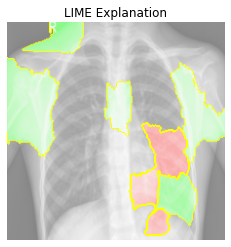

In [ ]:
import torchvision

from lime import lime_image
from skimage.segmentation import mark_boundaries

# Create a LimeImageExplainer object
explainer = lime_image.LimeImageExplainer()

# Function to predict and preprocess images for LIME
def predict_fn(images):
    # Move the images to the device
    images = torch.stack([torchvision.transforms.functional.to_tensor(image).to(device) for image in images])
    outputs = model(images)
    return outputs.softmax(dim=1).detach().cpu().numpy()

# Get a test image from the test_loader
dataiter = iter(test_loader)
images, labels = next(dataiter)
image = images[0]  # Select the first image

# Explain the instance using LIME
explanation = explainer.explain_instance(image.permute(1, 2, 0).numpy(),
                                         predict_fn,
                                         top_labels=2,
                                         hide_color=0,
                                         num_samples=1000)

# Get the image and mask
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=False,
                                            num_features=10,
                                            hide_rest=False)

# Display the LIME explanation
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.title("LIME Explanation")
plt.axis('off')
plt.show()


### LIME Explanation Inference

In the LIME explanation visualization, the chest X-ray is segmented into superpixels, with **red** regions indicating areas that had a strong **positive influence** on the model's prediction and **green** regions indicating areas with a **negative influence**. The red superpixels suggest that the model has identified specific regions of the lung that contribute heavily to the prediction. In the context of diagnosing conditions like pneumonia, these regions could correspond to areas of pathology, such as opacities or abnormalities in lung tissue. Meanwhile, the green areas represent regions that likely pushed the model away from a positive diagnosis and could correspond to normal tissue or irrelevant sections of the image.

The LIME explanation helps provide a localized understanding of the model's decision-making process, allowing for greater transparency. It is essential to validate these highlighted areas with clinical expertise to ensure that the model is making decisions based on relevant medical features. If the red areas align with known pathology, the model’s predictions can be trusted. However, if the highlighted regions do not correspond to clinically significant areas, the model may need further refinement to improve its focus and avoid relying on irrelevant features.


In [ ]:
pip install captum

Note: you may need to restart the kernel to use updated packages.


# Occlusion Sensitivity Attribution



---



**Occlusion Sensitivity Attribution** is a technique used to understand how specific regions of an image contribute to a machine learning model's prediction. This method works by systematically occluding (masking or covering) different parts of the input image and observing how the model’s prediction changes as a result. By doing this, we can identify which regions of the image are most important for the model’s decision-making process.

1. **How Occlusion Sensitivity Works**:  
   The technique involves sliding a small occlusion window (e.g., a black square or a blurred patch) over different regions of the image. For each position of the occlusion, the model's prediction is recorded. If occluding a particular region causes the model's confidence in its prediction to drop significantly, that region is considered important for the prediction.

2. **Visualization of Occlusion Sensitivity**:  
   After the entire image has been occluded and evaluated, a heatmap can be generated that shows the sensitivity of the model to different parts of the image. Regions where the model’s prediction changed the most due to occlusion are highlighted as important. These areas are often visualized in red or yellow to indicate their significance, while less important regions are visualized in blue or green.

3. **Application in Medical Imaging**:  
   In the context of medical imaging, occlusion sensitivity can be particularly useful for understanding which regions of an X-ray or other medical scans are driving the model’s predictions. For example, if a model is tasked with predicting pneumonia from a chest X-ray, occlusion sensitivity can reveal whether the model is focusing on pathological regions, such as areas with fluid buildup or tissue damage.

4. **Advantages of Occlusion Sensitivity**:  
   - **Simplicity**: Occlusion sensitivity is easy to implement and interpret, making it a straightforward method for generating model explanations.
   - **Model-Agnostic**: Since it only requires access to the model's output, this technique can be applied to any black-box model without needing to understand its inner workings.
   - **Localized Explanations**: It helps in understanding which specific parts of the image contributed to the model's prediction, giving insights into the model’s decision-making process.

5. **Limitations**:  
   - **Computation Time**: Occlusion sensitivity can be computationally expensive, especially for large images, as it requires repeatedly occluding different regions and passing the modified images through the model.
   - **Coarse Explanations**: The explanations produced by occlusion sensitivity can be coarse, depending on the size of the occlusion window. Smaller windows provide more detailed explanations but increase computation time, while larger windows reduce the granularity of the explanation.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


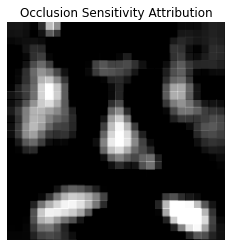

In [ ]:
import torch
from captum.attr import Occlusion

# Define the occlusion explainer
occlusion = Occlusion(model)

# Compute occlusion-based attributions
attributions = occlusion.attribute(input_image,
                                   strides=(3, 8, 8),
                                   sliding_window_shapes=(3, 15, 15),
                                   target=target_class)

# Convert attributions to numpy for visualization
attributions_np = attributions.squeeze().cpu().detach().numpy()

# Visualize the occlusion-based attributions
plt.imshow(attributions_np.transpose(1, 2, 0), cmap='hot')
plt.title('Occlusion Sensitivity Attribution')
plt.axis('off')
plt.show()


**Interpreting Occlusion Sensitivity Results**:  
   A heatmap generated from occlusion sensitivity shows the importance of different image regions. Regions where the occlusion causes the largest drop in prediction confidence are the most important for the model. If these regions align with clinically relevant features, such as lesions or abnormal tissue patterns in medical images, this indicates that the model is making medically sound decisions. However, if irrelevant areas are highlighted as important, this could indicate that the model is relying on spurious correlations in the data.



# Explanation of Layer-wise Relevance Propagation (LRP)



---

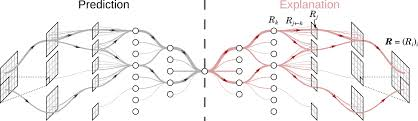

**Layer-wise Relevance Propagation (LRP)** is a technique used to explain the predictions of deep neural networks by backpropagating the model’s output relevance through each layer of the network. The goal of LRP is to determine how much each neuron in the network contributed to the final prediction, providing a clear attribution of relevance back to the input features (e.g., pixels in an image).

LRP works by redistributing the prediction score backward through the network, layer by layer, until it reaches the input. It ensures that the total relevance is conserved during the backward pass, allowing for a precise breakdown of how each input feature contributes to the model's prediction.

### Why LRP Prefers Complex Architectures Like ResNet

#### Layer Depth and Stability:
LRP works by propagating relevance backward through each layer of the network, ensuring that the total relevance is conserved. Simple CNNs often lack the necessary depth and stability (e.g., due to vanishing gradients) to handle this backward redistribution effectively. As a result, simple models might not preserve relevance well during backpropagation, leading to errors or poor explanations.

#### Complexity of Learned Features:
ResNet and other complex architectures are designed to handle deeper networks, which can learn more complex hierarchical features. LRP is typically more effective on these deep networks because they are better suited for hierarchical relevance attribution, especially in models that capture rich, abstract patterns in high-dimensional data (like images).

#### Skip Connections:
ResNets have skip connections that allow for the relevance to flow smoothly across layers during LRP. In simple CNNs, without skip connections, the relevance might not propagate effectively, causing instability or errors during the attribution process.

---

### Using LRP with Other Models

While LRP was initially designed for deep networks like ResNet, you can technically apply it to other models like simple CNNs, but you may face limitations. Here are some things to consider:

#### Model Complexity:
For LRP to work effectively on simpler models, you may need to ensure that the model has enough layers and that each layer contributes meaningfully to the decision. If the model is too shallow, relevance propagation may fail or become unstable.

#### Activation Functions:
Some errors with LRP can be due to specific activation functions. For example, certain non-linear activations might not handle relevance redistribution well. You can try using activation functions that are more conducive to LRP, such as ReLU.

#### Alternative XAI Methods:
If LRP continues to fail on your simple CNN, you could consider using alternative XAI techniques like **Grad-CAM**, **Occlusion Sensitivity**, or **LIME**, which are less sensitive to network depth and architecture. These methods may provide more robust explanations for simpler models.

---

### Recommendations

If you're facing issues with a simple CNN and LRP:
- Try increasing the depth of your network or adding **skip connections** to allow better gradient and relevance flow.
- Double-check the implementation of LRP to ensure it's compatible with your architecture.
- Consider switching to a more sophisticated model like ResNet, or use alternative XAI methods more suited to simpler models.


In [ ]:
# # Load a pretrained ResNet model as an example
model = models.resnet18(pretrained=True)
model.eval()

# If you have a custom-trained model, you would load that instead:
# model = CustomCNN()
# model.load_state_dict(torch.load('model_path'))

# # Move model to GPU if available
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = model.to(device)


The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:

def train_model(model, train_loader, criterion, optimizer, num_epochs=40):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}')

train_model(model, train_loader, criterion, optimizer, num_epochs=5)


In [ ]:
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Accuracy: {100 * correct / total:.2f}%')

evaluate_model(model, test_loader)


In [ ]:
from captum.attr import LRP

# Initialize Layer-wise Relevance Propagation
lrp = LRP(model)

# Compute LRP attributions
attributions_lrp = lrp.attribute(input_image, target=target_class)

# Convert LRP attributions to numpy for visualization
attributions_lrp_np = attributions_lrp.squeeze().cpu().detach().numpy()

# Visualize LRP attributions
plt.imshow(attributions_lrp_np.transpose(1, 2, 0), cmap='hot')
plt.title('LRP Attribution')
plt.axis('off')
plt.show()
